**Dataset Link** - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams/                                               
**Description** - The dataset used in this project is titled “Students Performance in Exams”, sourced from the Kaggle public repository. It contains academic performance data of 1,000 high school students along with their demographic and socio-economic attributes.


**Objective:**
To predict students’ overall academic performance using machine learning models and identify key factors affecting their exam scores.

We will now import the necessary Python libraries to perform this analysis. These include tools for data manipulation (pandas), visualization (Matplotlib, Seaborn), statistical testing (scipy.stats), and machine learning (scikit-learn).

In [49]:
import pandas as pd
import numpy as np
import sklearn.preprocessing as sk
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import sklearn.model_selection as skms
import sklearn.linear_model as sklm
import sklearn.metrics as skm

In [3]:
df = pd.read_csv("StudentsPerformance.csv")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
print("Dataset Shape:")
df.shape

Dataset Shape:


(1000, 8)

In [6]:
print("Column Names:")
df.columns.tolist()

Column Names:


['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [7]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
print("Data Types:")
print(df.dtypes)

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


| Column Name                   | Type of Variable       | Explanation                                                   |
| ----------------------------- | ---------------------- | ------------------------------------------------------------- |
| `gender`                      | Categorical (Nominal)  | Represents category with no numeric ordering (male/female)    |
| `race/ethnicity`              | Categorical (Nominal)  | Group labels (A–E), no rank/order                             |
| `parental level of education` | Categorical (Ordinal)  | Education level has a natural order (HS → College → Master’s) |
| `lunch`                       | Categorical (Nominal)  | Types of lunch benefit (standard/free-reduced)                |
| `test preparation course`     | Categorical (Ordinal)  | Completed vs not completed (ordered in terms of improvement)  |
| `math score`                  | Numerical (Continuous) | Score range 0–100                                             |
| `reading score`               | Numerical (Continuous) | Score range 0–100                                             |
| `writing score`               | Numerical (Continuous) | Score range 0–100                                             |


# Data Cleaning & Preparation #

### 1. Check for missing values and handle them appropriately (imputation or removal). ###
We will check every column for empty or NaN values and decide on a strategy (like removal or imputation) to ensure our dataset is complete.

In [10]:
# Check missing values
print("\nMissing values per column:")
df.isnull().sum()


Missing values per column:


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

* The output of .isnull().sum() shows '0' for every column.
* This confirms our dataset has no missing values, so no imputation  or removal is needed for this step."

### 2. Remove duplicates and irrelevant columns. ###
We will find and delete any rows that are exact copies of another, as well as remove any columns that provide no useful information for our model.

In [11]:
# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


* No DUPLICATES found.

### 3. Handle outliers using suitable methods ###

 We will use statistical methods to identify and review extreme data points (like unusually high Data Points) that could negatively affect our model's accuracy.

I am keeping outliers because they represent real, High Scores, which is essential information for an academic performance prediction model.

Exam scores are naturally bounded (0–100), so outliers may not be real anomalies.

### 4. Encoding categorical data ###

In [12]:
df_processed = df.copy()
df_processed.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
# Label encode ordinal columns
label_cols = ['parental level of education', 'test preparation course']
le = sk.LabelEncoder()
for col in label_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

In [14]:
# One-hot encode nominal columns
df_processed = pd.get_dummies(df_processed, columns=['gender', 'race/ethnicity', 'lunch'], drop_first=True)

In [15]:
df_processed.head()

,parental level of education,test preparation course,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard
0,1,1,72,72,74,False,True,False,False,False,True
1,4,0,69,90,88,False,False,True,False,False,True
2,3,1,90,95,93,False,True,False,False,False,True
3,0,1,47,57,44,True,False,False,False,False,False
4,4,1,76,78,75,True,False,True,False,False,True


### 5. Normalize or scale data if required. ###

In [16]:
# Create average score column
df_processed['avg_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

df_processed[['math score', 'reading score', 'writing score', 'avg_score']].head()


,math score,reading score,writing score,avg_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


In [17]:
# keep original for analysis
df_scaled = df_processed.copy()

scaler = sk.StandardScaler()

numeric_cols = ['math score', 'reading score', 'writing score', 'avg_score']
df_scaled[numeric_cols] = scaler.fit_transform(df_scaled[numeric_cols])

df_scaled.head()

,parental level of education,test preparation course,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,lunch_standard,avg_score
0,1,1,0.390024,0.193999,0.391492,False,True,False,False,False,True,0.343574
1,4,0,0.192076,1.427476,1.313269,False,False,True,False,False,True,1.021927
2,3,1,1.577711,1.770109,1.642475,False,True,False,False,False,True,1.747064
3,0,1,-1.259543,-0.833899,-1.583744,True,False,False,False,False,False,-1.293830
4,4,1,0.653954,0.605158,0.457333,True,False,True,False,False,True,0.600881


# Exploratory Data Analysis (EDA) #

## Univariate analysis ##

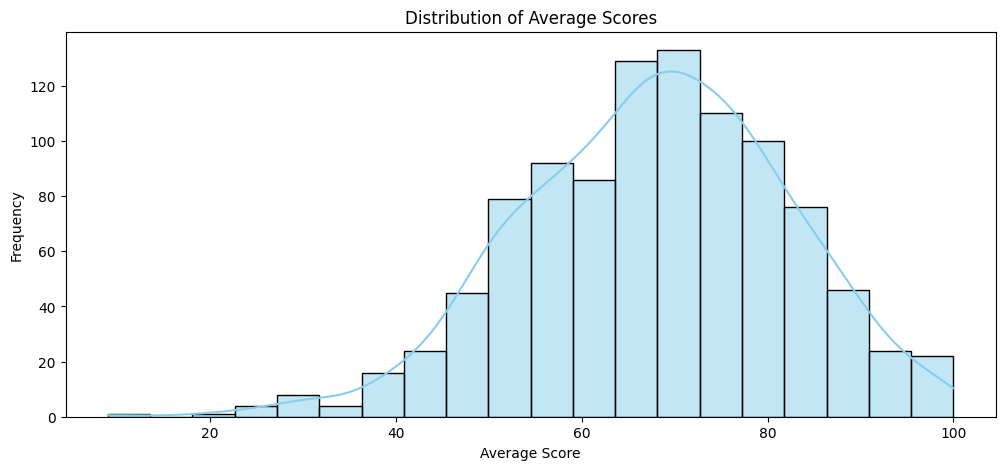

In [18]:
plt.figure(figsize=(12, 5))
sns.histplot(df_processed['avg_score'], kde=True, bins=20, color='skyblue')
plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Frequency")
plt.show()


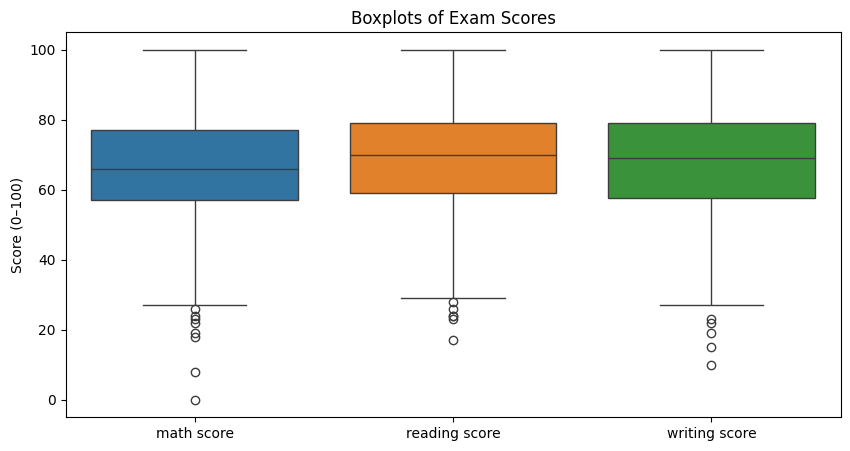

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_processed[['math score', 'reading score', 'writing score']])
plt.title("Boxplots of Exam Scores")
plt.ylabel("Score (0–100)")
plt.show()


Insights: Outliers and Anomalies

* A few low score outliers exist (very low performing students).

* A few high-end scores near 100 also appear (very high performers).

* However, no extreme or unrealistic outliers appear → data is clean and realistic.

* Outliers are natural in exam datasets and do not require removal.

## Bivariate/multivariate analysis ##

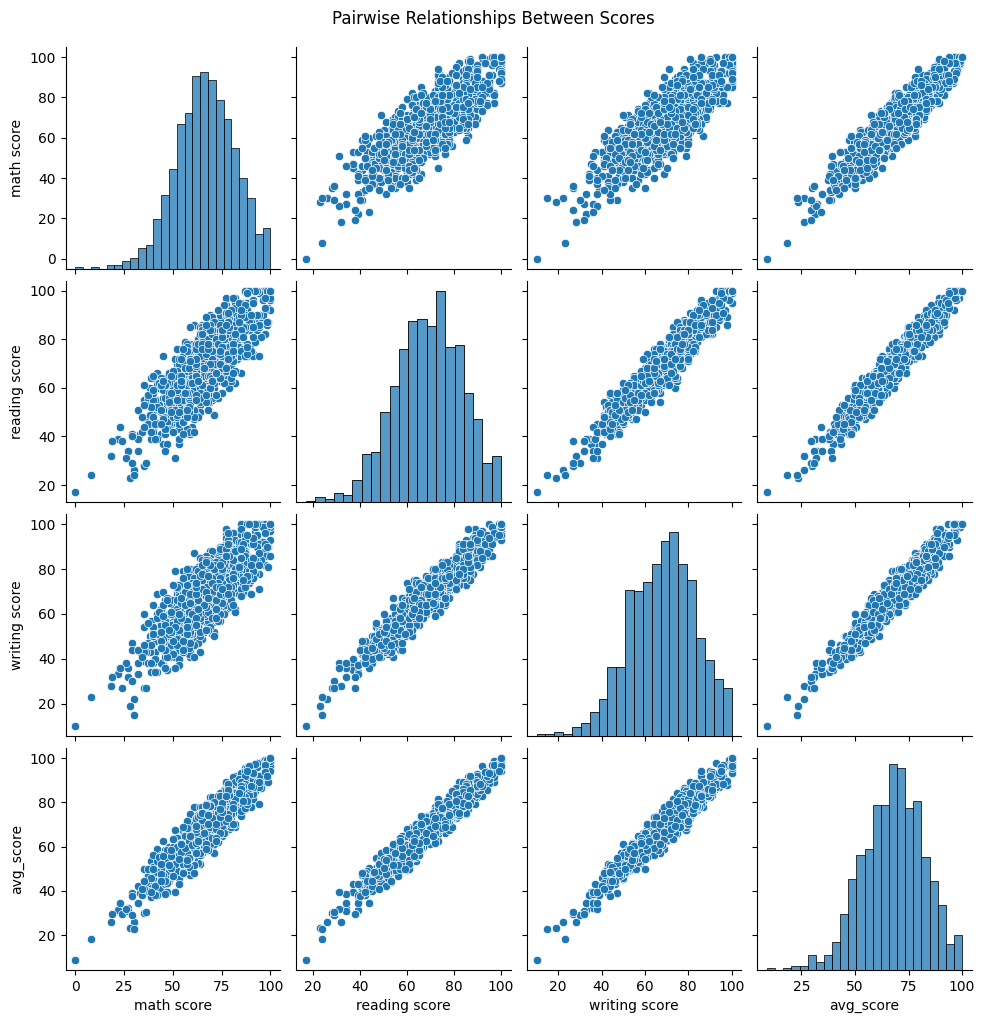

In [20]:
sns.pairplot(df_processed[['math score', 'reading score', 'writing score', 'avg_score']])
plt.suptitle("Pairwise Relationships Between Scores", y=1.02)
plt.show()


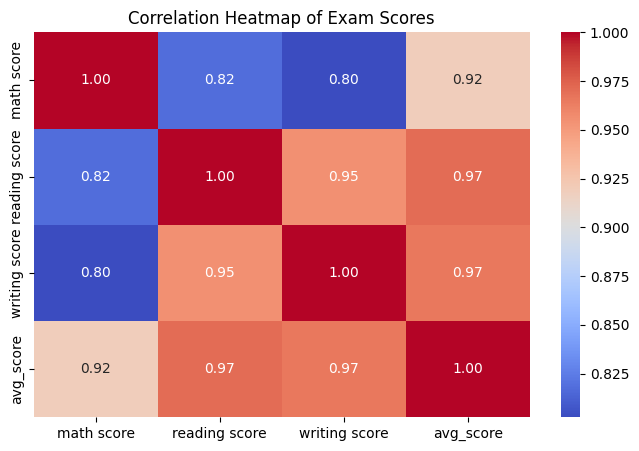

In [21]:
plt.figure(figsize=(8, 5))
sns.heatmap(df_processed[['math score', 'reading score', 'writing score', 'avg_score']].corr(), annot = True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Exam Scores")
plt.show()


## descriptive statistics ##

In [22]:
# Descriptive statistics for numeric features
df_processed[['math score', 'reading score', 'writing score', 'avg_score']].describe()

,math score,reading score,writing score,avg_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


In [23]:
prep_mean = df_processed.groupby('test preparation course')['avg_score'].mean()
print(prep_mean)
# 1 = none
# 0 = completed

test preparation course
0    72.669460
1    65.038941
Name: avg_score, dtype: float64


In [24]:
lunch_mean = df_processed.groupby('lunch_standard')['avg_score'].mean()
print(lunch_mean)

lunch_standard
False    62.199061
True     70.837209
Name: avg_score, dtype: float64


In [25]:
parent_mean = df_processed.groupby('parental level of education')['avg_score'].mean().sort_values()
print(parent_mean)

parental level of education
2    63.096939
5    65.108007
4    68.476401
0    69.569069
1    71.923729
3    73.598870
Name: avg_score, dtype: float64


In [26]:
gender_mean = df_processed.groupby('gender_male')[['math score','reading score','writing score']].mean()
print(gender_mean)

             math score  reading score  writing score
gender_male                                          
False         63.633205      72.608108      72.467181
True          68.728216      65.473029      63.311203


In [75]:
# Descriptive Statistics: Mean, Median, Std, Skewness, Kurtosis
num_cols = ['math score', 'reading score', 'writing score', 'avg_score']

stats_df = pd.DataFrame(columns=['Mean', 'Median', 'Std Dev', 'Skewness', 'Kurtosis'])

for col in num_cols:
    stats_df.loc[col, 'Mean'] = df_processed[col].mean()
    stats_df.loc[col, 'Median'] = df_processed[col].median()
    stats_df.loc[col, 'Std Dev'] = df_processed[col].std()
    stats_df.loc[col, 'Skewness'] = df_processed[col].skew()
    stats_df.loc[col, 'Kurtosis'] = df_processed[col].kurt()

stats_df


,Mean,Median,Std Dev,Skewness,Kurtosis
math score,66.089,66.0,15.16308,-0.278935,0.274964
reading score,69.169,70.0,14.600192,-0.259105,-0.068265
writing score,68.054,69.0,15.195657,-0.289444,-0.033365
avg_score,67.770667,68.333333,14.257326,-0.299057,0.125843


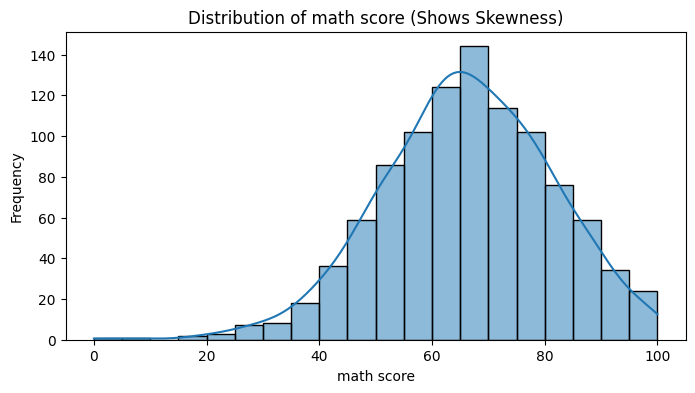

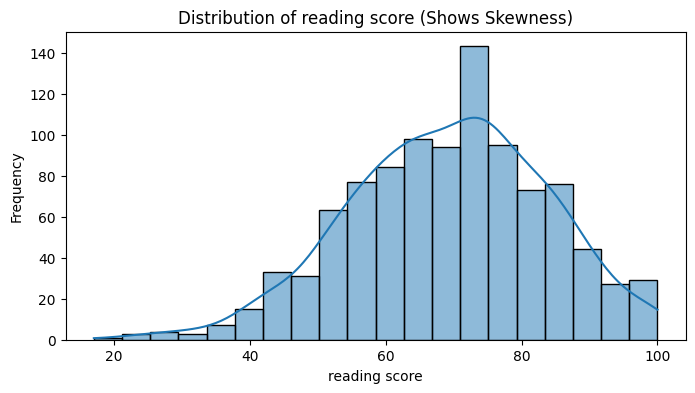

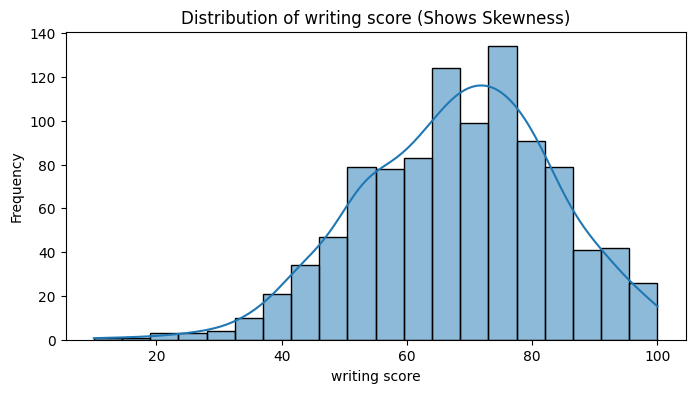

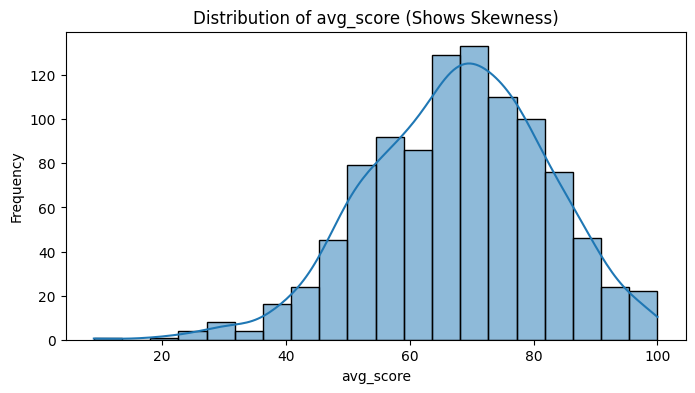

In [30]:
num_cols = ['math score', 'reading score', 'writing score', 'avg_score']

for col in num_cols:
    plt.figure(figsize=(8,4))
    

    sns.histplot(df_processed[col], kde=True, bins=20)
    plt.title(f"Distribution of {col} (Shows Skewness)")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### 4.Patterns and Insights from the Dataset ###
* In this section, we identify key patterns and trends based on correlations, group-wise analysis, and visual behavior of score distributions. These insights help us understand which factors most strongly influence student performance.

* Insights from Correlation Heatmap :

    * All three subjects (math, reading, writing) have strong positive correlations with each other (r ≈ 0.8–0.95).

    * This means students who perform well in one subject tend to perform well in others.

    * avg_score is strongly correlated with all three subjects, confirming it is a reliable composite performance measure.

    * No negative correlations were found, indicating no inverse relationships between features.

### Insights from Group-Wise Trends ###
    1️ Gender

        * Males perform slightly better in math.

        * Females tend to outperform males in reading and writing.

        * Overall average score difference is small → no major gender performance gap.
        
    2 Parental Level of Education

        * Clear upward trend: higher parental education → higher student performance.

        * Students whose parents have a master’s degree tend to achieve the highest scores.

        * Home educational environment has a meaningful impact.

    3️ Lunch Type (Socio-economic Status)

        * Students with standard lunch score significantly higher.

        * Students with free/reduced lunch score lower on average.

        * Indicates socio-economic conditions strongly influence academic performance.

    4 Test Preparation Course

        * Students who completed the test prep course have much higher average scores.

        * Suggests structured preparation has a significant positive effect.

## Step 4: Statistical Analysis & Hypothesis Testing ##
 Goal: use inferential statistics to validate the EDA insights (test-prep effect, parental education differences).


Hypotheses to test

Hypothesis  — Effect of Test Preparation (Two-sample t-test)

* Null (H₀): There is no difference in mean avg_score between students who completed the test preparation course and those who did not.

* Alternative (H₁): Students who completed the test preparation course have a higher mean avg_score than students who did not.

* Test: Independent two-sample t-test (Welch’s t-test, unequal variances), one-tailed.

Significance level: α = 0.05.

In [73]:
# Hypothesis Test: Effect of Test Preparation Course on avg_score
# Groups: 0 = completed, 1 = none

completed = df_processed[df_processed['test preparation course'] == 0]['avg_score']
none = df_processed[df_processed['test preparation course'] == 1]['avg_score']

mean_completed = completed.mean()
mean_none = none.mean()

# Welch's t-test
t_stat, p_value = stats.ttest_ind(completed, none, equal_var=False)

# Mean difference
mean_diff = mean_completed - mean_none

# Standard error
se = np.sqrt(completed.var(ddof=1)/len(completed) + none.var(ddof=1)/len(none))

# 95% Confidence Interval 
dfree = min(len(completed), len(none)) - 1
t_crit = stats.t.ppf(0.975, dfree)
ci_low = mean_diff - t_crit * se
ci_high = mean_diff + t_crit * se

print("Effect of Test Preparation Course on avg_score")
print(f"Mean (completed): {mean_completed:.3f}")
print(f"Mean (none):      {mean_none:.3f}")
print(f"Mean difference:  {mean_diff:.3f}")
print(f"t-statistic:      {t_stat:.3f}")
print(f"p-value:          {p_value:.10f}")
print(f"95% CI:           ({ci_low:.3f}, {ci_high:.3f})")

# Hypothesis decision
alpha = 0.05  # significance level

print("\nDecision:")
if p_value < alpha:
    print(f"Since p-value ({p_value:.10f}) < 0.05, we REJECT the Null Hypothesis (H0).")
    print("Conclusion: Students who completed the test-preparation course score significantly higher.")
else:
    print(f"Since p-value ({p_value:.10f}) >= 0.05, we FAIL TO REJECT the Null Hypothesis (H0).")
    print("Conclusion: There is no statistically significant difference in scores.")



Effect of Test Preparation Course on avg_score
Mean (completed): 72.669
Mean (none):      65.039
Mean difference:  7.631
t-statistic:      8.595
p-value:          0.0000000000
95% CI:           (5.884, 9.377)

Decision:
Since p-value (0.0000000000) < 0.05, we REJECT the Null Hypothesis (H0).
Conclusion: Students who completed the test-preparation course score significantly higher.


### P-Value Interpretation ###

* The computed p-value for the difference in average scores between students who completed the test-preparation course and those who did not was reported as 0.00000 (effectively ≈ 0, i.e. far smaller than typical machine-print thresholds). In practical terms this means p ≪ 0.05 (for example, p < 1e-10).

* This p-value is much smaller than our significance level of α = 0.05.

Conclusion: Because the p-value is so extremely small, we REJECT the Null Hypothesis (H₀). The result is highly statistically significant and provides very strong evidence that the observed difference in average scores is not due to random chance.

### Confidence Interval Interpretation ###

* The 95% confidence interval for the mean difference (completed − none) is (5.884, 9.373) points.

* What this means: we are 95% confident that the true average improvement in avg_score associated with completing the test-preparation course lies somewhere between ≈ 5.9 and 9.4 points.

Conclusion: The interval does not include 0, which is consistent with the p-value result and confirms that there is a real, positive difference in performance associated with completing the course. Practically speaking, completing the course is associated with an average gain of about 6–9 points.

## Discuss Type I and Type II Errors ##
### Type I Error (False Positive) ###
* What it is: A Type I error happens when I reject the Null Hypothesis even though it is actually true.
* My Context: In my analysis, this would mean:

   * I concluded that students who completed the test-preparation course score higher, but in reality there is no real difference between the two groups.
   * I would have been misled by a rare, unusual sample.
* Relevance:
    * The probability of a Type I error is my chosen significance level,
        α = 0.05 (5%).

    * However, my actual p-value is essentially 0 (far below 0.05), so:

       * The chance that this result is a Type I error is extremely small.

       * There is strong evidence that the difference in mean scores is real, not random.
     
### Type II Error (False Negative) ###

* What it is: A Type II error happens when I fail to reject the Null Hypothesis even when it is false.

* My Context: This would happen if:

    * I concluded “there is no difference between the groups,” even though students who completed the test-prep course actually do perform better.

* Relevance:
 * This error is not relevant to my case, because I did detect a significant difference.

 * But in an educational context, making a Type II error would be important:

 * Schools might wrongly assume that test-preparation programs provide no benefit.

 * As a result, they might not invest in such programs, causing students to miss out on a real improvement of 6–9 points.

 * This could lead to poorer exam outcomes and lost opportunities for students.

## ***Step 5: Modeling and Pattern Discovery***

**Option A (Regression)**
* Regression is a technique used to predict a specific, continuous numerical value, like a price or temperature. 

**Option B(Clustering/Classification)**
* On the other hand, involves either Clustering (which finds hidden groups in data) or Classification (which predicts a distinct category, like "Yes" or "No").

### For this project, Option A (Regression) is the correct modeling method because it directly matches the goal of predicting a continuous outcome variable (avg_score). ###
### Option B is unsuitable because it cannot predict an exact numerical score. ###

## Steps in Building My Regression Model ##

**1. Split Data:**
I will divide the dataset into an 80% training set (where the model learns patterns) and a 20% testing set (used to check how well the model performs on unseen data).

**2. Scale Data:**
I will standardize the numerical features so that all of them are on a similar scale. This prevents larger-valued features from dominating the model and avoids data leakage by fitting the scaler only on the training set.

**3. Train Model:**
I will create a Linear Regression model and train it using the training data so it can learn how different factors (like lunch, gender, and parental education) affect a student’s average score.

**4. Evaluate Model:**
I will test the model on the 20% testing data and assess its performance using R², RMSE, and MAE, which tell me how accurate and reliable my predictions are.

In [52]:
# 1. Select features & target
# We drop avg_score from features because it is the target we want to predict
X = df_processed.drop(['avg_score', 'math score', 'reading score', 'writing score'], axis=1)
y = df_processed['avg_score']


In [53]:
# 2. Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = skms.train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [55]:
# 3. Train Linear Regression Model
model = sklm.LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [58]:
# 4. Make predictions
y_pred = model.predict(X_test)


In [60]:
# Create a comparison DataFrame
comparison = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': y_pred
})

comparison.head(20)   


,Actual Score,Predicted Score
0,87.000000,70.761634
1,64.000000,66.072442
2,75.000000,68.889091
3,74.666667,55.054597
4,81.666667,77.615352
5,78.000000,60.303777
6,67.333333,63.947494
7,59.000000,74.657756
8,77.333333,57.275386
9,48.666667,70.312020


In [63]:
# 6. Evaluate Model
r2 = skm.r2_score(y_test, y_pred)
rmse = np.sqrt(skm.mean_squared_error(y_test, y_pred))
mae = skm.mean_absolute_error(y_test, y_pred)

print("Model Evaluation Metrics")
print(f"R² Score                       :{r2:.4f}")
print(f"Root Mean Squared Error (RMSE) :{rmse:.4f}")
print(f"Mean Absolute Error (MAE)      :{mae:.4f}")

Model Evaluation Metrics
R² Score                       :0.1139
Root Mean Squared Error (RMSE) :13.7822
Mean Absolute Error (MAE)      :10.8408


## R-squared (R²): 0.1139 ##

What it is:
The percent of variation in avg_score that the model can explain.

Interpretation:
My R² is 0.11, which means the model explains only 11% of the variation in student performance.
This is expected because demographic features (gender, lunch, parental education, etc.) cannot fully predict exact exam scores.

## Mean Absolute Error (MAE): 10.84 ##

What it is:
The average amount by which the predictions were “off.”

Interpretation:
On average, my model’s prediction is wrong by about 10.8 points.
This shows the model gives rough estimates, not highly accurate score predictions.

## Root Mean Squared Error (RMSE): 13.78 ##

What it is:
Similar to MAE but penalizes larger errors more strongly.

Interpretation:
RMSE is higher than MAE, meaning the model makes a few larger mistakes on certain students.
These bigger errors raise the RMSE value.

# Step 6: Interpretation & Inference #
## Major Findings from EDA ##

    From the exploratory data analysis, several clear patterns emerged:

    Students who completed the test-preparation course consistently scored higher.

    Parental level of education showed a positive trend: higher-educated parents → higher student scores.

    Students with standard lunch performed better than those with free/reduced lunch, indicating socioeconomic influence.

    All three exam scores (math, reading, writing) were strongly correlated, showing that academic performance tends to move together across subjects.

## Insights and Significance ##

    These findings highlight the importance of academic support (test prep), family background (parental education), and socioeconomic conditions (lunch type) in shaping student performance.
    
    The results can help educators identify which groups may benefit most from additional resources, tutoring, or academic interventions.

## Role of Statistical Testing ##

The t-test confirmed what the EDA suggested:
    
   * Students who completed the test-preparation course scored 6–9 points higher on average, and this difference was highly statistically significant (p-value ≈ 0).

   * The confidence interval did not include 0, strengthening the conclusion.

This validates that the observed difference was not due to random chance.

## Modeling Insights

The regression model using demographic features had:

* R² = 0.11, showing that only about 11% of score variation can be predicted from demographics alone.

* MAE ≈ 10.8 and RMSE ≈ 13.8, meaning predictions were often 10–14 points away from actual scores.

This indicates that demographic factors explain general trends but cannot accurately predict exact exam scores, which depend on many unmeasured factors.

## What could be improved with more data or features?

My model’s R² is 11.39%, which means nearly 88% of student performance is still unexplained. To improve the model, I would need:

* **More Features**:
This is the biggest limitation. Academic performance depends on many factors that are missing from the dataset.
Adding features like study habits, attendance, tuition/coaching, homework hours, previous grades, family environment, and access to resources would almost certainly improve prediction accuracy.

* **A Better Model**:
Linear Regression is simple and may not capture the complex interactions between socioeconomic factors.
A more advanced model like Random Forest, XGBoost, or Neural Networks could learn non-linear relationships and increase the R² score.

* **Better Target Choice**:
Predicting an exact exam score is difficult because scores fluctuate due to many random factors.
Predicting something simpler — like pass/fail, high/medium/low performer, or improvement trend — might give more accurate results.

# ***Step 7: Visualization and Presentation***


**Description:** For this step, the most meaningful visualization is one that shows the performance of model. I created a scatterplot that directly compares the model's Predicted Charges (on the y-axis) against the Actual Charges (on the x-axis) from the 20% test set. This plot is the best way to "see" how good the model's $R^2$ score is in practice.

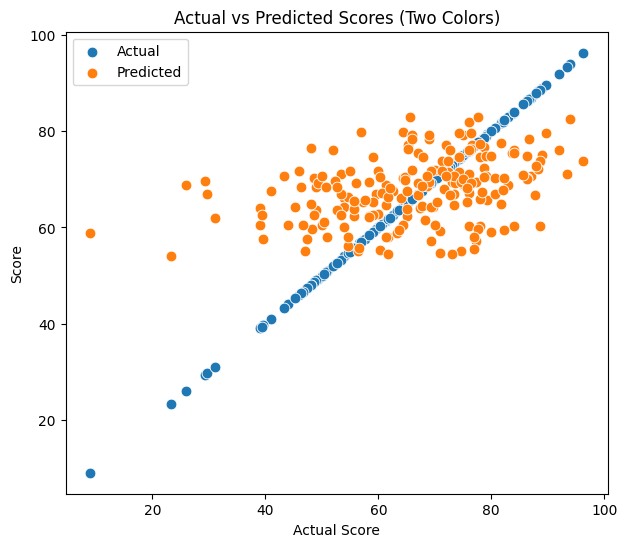

In [69]:
plt.figure(figsize=(7,6))

# Actual points
sns.scatterplot(x=y_test, y=y_test, label="Actual", s=60)

# Predicted points
sns.scatterplot(x=y_test, y=y_pred, label="Predicted", s=60)

plt.title("Actual vs Predicted Scores (Two Colors)")
plt.xlabel("Actual Score")
plt.ylabel("Score")
plt.legend()
plt.show()


**Findings (Actual vs Predicted Plot)**

The blue points (actual scores) form a perfect diagonal line, while the orange points (predicted scores) scatter around it.
This shows that the model captures the general trend but struggles to predict exact scores.
Many predictions fall noticeably above or below the diagonal, indicating errors of around 10–15 points.
Overall, the plot confirms that the model provides rough estimates, not precise predictions.

## Step 8: Conclusion

**1. Summary of Findings and Conclusions**

In this project, I analyzed a student performance dataset and applied data preprocessing, exploratory analysis, statistical inference, and regression modeling to understand the key factors that influence academic scores. The EDA revealed clear patterns: students who completed the test-preparation course, those with higher parental education, and students receiving a standard lunch tended to perform better. The t-test statistically confirmed that test-preparation has a significant positive impact, with students scoring 6–9 points higher on average.

The regression model, built using demographic and socioeconomic features, achieved an R² of 0.11, showing that these factors explain only a small portion of the variation in scores. The model’s MAE (~ 10.8) and RMSE (~ 13.7) indicate that predictions are approximate rather than precise, which is expected because many key academic factors (study habits, motivation, attendance, etc.) were not included in the dataset.

Overall, the analysis highlights that socioeconomic support and academic preparation play important roles in student performance, but predicting exact scores requires richer, behavioral-level data. Future work could include additional features, more advanced machine-learning models, and larger datasets to achieve higher predictive accuracy.

**2. Limitations**

The dataset lacks important academic factors such as study habits, attendance, motivation, and past performance, which limits prediction accuracy.

Only demographic and socioeconomic features were available, so the model cannot capture the full complexity of student performance.

A simple linear regression model may not fully represent non-linear relationships between student characteristics and exam scores.

**3. Key Takeaways**

This project showed that student performance is influenced by test preparation, parental education, and socioeconomic factors, as visible in the EDA patterns. Statistical testing confirmed that completing the test-preparation course significantly improves scores, with a strong p value and a clear confidence interval. However, the regression model demonstrated that demographics alone cannot accurately predict exact exam scores, explaining only about 11% of the variation. Overall, while the dataset highlights meaningful educational trends, it also shows that academic performance is complex and heavily influenced by additional factors not captured in the data.

## AI Declaration 
I used ChatGPT to assist with some parts of this project.
The tool was used for:

* Writing explanations, inferences, and Markdown summaries

* Improving clarity of interpretations

* Structuring the workflow for EDA, hypothesis testing, and regression